In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [2]:
from huggingface_hub import login

# Replace 'your_token_here' with the token from your Hugging Face settings
# (Profile -> Settings -> Access Tokens -> New Token)
login(token="token here")

In [3]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import timm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from sklearn.metrics import roc_auc_score, classification_report

# Setup Project Root (Adjust if your folder structure is different)
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
from timm.layers import resample_abs_pos_embed

class QuantumDeiT(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        # 1. Load pretrained DeiT-Tiny
        self.backbone = timm.create_model('deit_tiny_patch16_224', pretrained=pretrained)
        self.embed_dim = self.backbone.num_features # 192
        
        # 2. Resize Position Embeddings to 82 (1 CLS + 81 patches)
        num_patches = 9 * 9
        new_pos_embed = resample_abs_pos_embed(
            self.backbone.pos_embed, 
            new_size=(9, 9), 
            num_prefix_tokens=1 
        )
        self.backbone.pos_embed = nn.Parameter(new_pos_embed)
        
        # 3. Adapter
        self.quantum_projection = nn.Conv2d(36, self.embed_dim, kernel_size=1)
        
        # 4. Head
        self.backbone.head = nn.Linear(self.embed_dim, num_classes)
        
        # 5. REMOVE the Identity override to let backbone use its internal logic
        # But we will bypass it in forward() anyway

    def forward(self, x):
        # x: [Batch, 36, 9, 9]
        x = self.quantum_projection(x) # [Batch, 192, 9, 9]
        
        # Reshape to Tokens: [Batch, 81, 192]
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        
        # --- THE FIX ---
        # Instead of adding CLS token ourselves and calling forward_features,
        # we manually perform the steps forward_features does to stay in control.
        
        # 1. Add the CLS token
        cls_token = self.backbone.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1) # [Batch, 82, 192]
        
        # 2. Add the position embedding we resized
        x = x + self.backbone.pos_embed
        
        # 3. Pass through the Transformer blocks directly
        x = self.backbone.pos_drop(x)
        x = self.backbone.blocks(x)
        x = self.backbone.norm(x)
        
        # 4. Final Class Prediction
        logits = self.backbone.forward_head(x)
        return logits

model = QuantumDeiT(num_classes=2, pretrained=True).to(device)

In [5]:
class QuantumFeatureDataset(Dataset):
    def __init__(self, npz_path, split='train'):
        data = np.load(npz_path, allow_pickle=True)
        self.features = torch.from_numpy(data[f'{split}_features']).float()
        self.labels = torch.from_numpy(data[f'{split}_labels']).long()

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

CACHE_PATH = PROJECT_ROOT / "data" / "quantum_datasets" / "breast_mnist_vit_k3_s3_custom.npz"

train_ds = QuantumFeatureDataset(CACHE_PATH, 'train')
val_ds = QuantumFeatureDataset(CACHE_PATH, 'val')
test_ds = QuantumFeatureDataset(CACHE_PATH, 'test')

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [6]:
def set_trainable_mode(model, phase="warmup"):
    if phase == "warmup":
        for param in model.backbone.parameters(): param.requires_grad = False
        for param in model.backbone.head.parameters(): param.requires_grad = True
        for param in model.quantum_projection.parameters(): param.requires_grad = True
    else:
        for param in model.parameters(): param.requires_grad = True

# --- HYPERPARAMETERS ---
WARMUP_EPOCHS = 100
TOTAL_EPOCHS = 400
criterion = nn.CrossEntropyLoss()
history = {'train_acc': [], 'val_acc': []}

# START WARMUP
set_trainable_mode(model, "warmup")
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

for epoch in range(TOTAL_EPOCHS):
    if epoch == WARMUP_EPOCHS:
        set_trainable_mode(model, "finetune")
        # Lower LR for fine-tuning
        optimizer = optim.AdamW(model.parameters(), lr=1e-5)
    
    model.train()
    correct, total = 0, 0
    for feats, lbls in train_loader:
        feats, lbls = feats.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(feats)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        correct += (outputs.argmax(1) == lbls).sum().item()
        total += lbls.size(0)
    
    # Validation
    model.eval()
    v_correct = 0
    with torch.no_grad():
        for feats, lbls in val_loader:
            feats, lbls = feats.to(device), lbls.to(device)
            v_correct += (model(feats).argmax(1) == lbls).sum().item()
    
    t_acc, v_acc = 100*correct/total, 100*v_correct/len(val_ds)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    mode = "Warmup" if epoch < WARMUP_EPOCHS else "Fine-tune"
    if (epoch+1) % 5 == 0:
        print(f"[{mode}] Epoch {epoch+1} | Train: {t_acc:.2f}% | Val: {v_acc:.2f}%")

[Warmup] Epoch 5 | Train: 75.82% | Val: 73.08%
[Warmup] Epoch 10 | Train: 78.94% | Val: 78.21%
[Warmup] Epoch 15 | Train: 81.32% | Val: 76.92%
[Warmup] Epoch 20 | Train: 82.23% | Val: 76.92%
[Warmup] Epoch 25 | Train: 81.68% | Val: 82.05%
[Warmup] Epoch 30 | Train: 84.43% | Val: 84.62%
[Warmup] Epoch 35 | Train: 87.91% | Val: 88.46%
[Warmup] Epoch 40 | Train: 86.81% | Val: 84.62%
[Warmup] Epoch 45 | Train: 89.56% | Val: 89.74%
[Warmup] Epoch 50 | Train: 90.29% | Val: 88.46%
[Warmup] Epoch 55 | Train: 93.04% | Val: 89.74%
[Warmup] Epoch 60 | Train: 94.14% | Val: 89.74%
[Warmup] Epoch 65 | Train: 94.51% | Val: 88.46%
[Warmup] Epoch 70 | Train: 96.70% | Val: 91.03%
[Warmup] Epoch 75 | Train: 97.62% | Val: 88.46%
[Warmup] Epoch 80 | Train: 98.35% | Val: 89.74%
[Warmup] Epoch 85 | Train: 99.27% | Val: 91.03%
[Warmup] Epoch 90 | Train: 99.63% | Val: 87.18%
[Warmup] Epoch 95 | Train: 99.27% | Val: 91.03%
[Warmup] Epoch 100 | Train: 100.00% | Val: 88.46%
[Fine-tune] Epoch 105 | Train: 99.08% |

In [8]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        
        # Get probability for the positive class (Malignant)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

<Figure size 600x500 with 0 Axes>

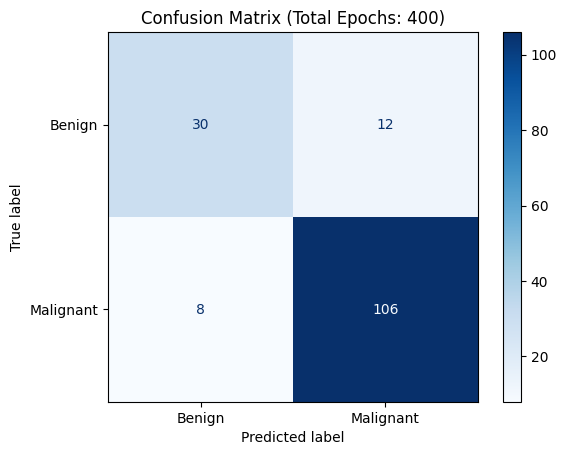

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Total Epochs: 400)')
plt.show()

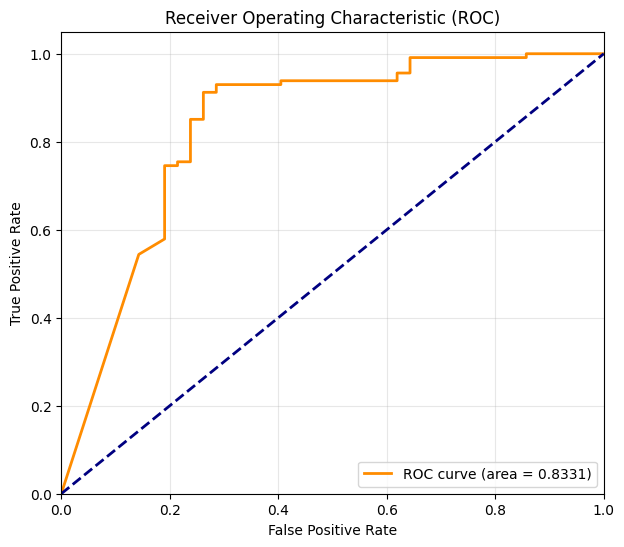

Final Test AUC: 0.8331


In [10]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final Test AUC: {roc_auc:.4f}")

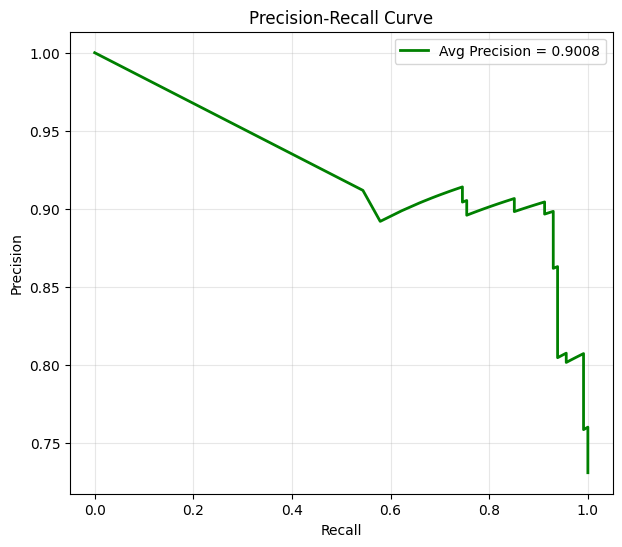

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Set model to evaluation mode
model.eval()

y_true = []
y_probs = []
y_preds = []

# 2. Collect predictions without calculating gradients (saves memory/time)
with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        
        # Forward pass
        logits = model(features)
        
        # Get probabilities (using Softmax)
        probs = torch.softmax(logits, dim=1)
        
        # Get the predicted class (0 or 1)
        preds = torch.argmax(logits, dim=1)
        
        # Move back to CPU for sklearn
        y_true.extend(labels.numpy())
        y_probs.extend(probs[:, 1].cpu().numpy()) # Probability of class 1 (Malignant)
        y_preds.extend(preds.cpu().numpy())

# 3. Calculate Final Metrics
final_acc = accuracy_score(y_true, y_preds)
final_auc = roc_auc_score(y_true, y_probs)

# 4. Print Results
print("-" * 30)
print(f"FINAL TEST RESULTS (400 Epochs)")
print("-" * 30)
print(f"Accuracy (ACC): {final_acc * 100:.2f}%")
print(f"Area Under Curve (AUC): {final_auc:.4f}")
print("-" * 30)

# 5. Detailed Classification Report (Precision, Recall, F1)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_preds, target_names=['Benign', 'Malignant']))

------------------------------
FINAL TEST RESULTS (400 Epochs)
------------------------------
Accuracy (ACC): 87.18%
Area Under Curve (AUC): 0.8331
------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.79      0.71      0.75        42
   Malignant       0.90      0.93      0.91       114

    accuracy                           0.87       156
   macro avg       0.84      0.82      0.83       156
weighted avg       0.87      0.87      0.87       156

